<a href="https://colab.research.google.com/github/MalakMaher780/Projects-/blob/main/Analysis_of_time_series_data_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Load + Prepare Data
import pandas as pd
df = pd.read_csv("/content/1_Daily_minimum_temps.csv")
print(df.head())
print(df.columns)

       Date  Temp
0  01/01/81  20.7
1  01/02/81  17.9
2  01/03/81  18.8
3  01/04/81  14.6
4  01/05/81  15.8
Index(['Date', 'Temp'], dtype='object')


In [ ]:
df["Temp"] = pd.to_numeric(df["Temp"], errors="coerce")

In [ ]:
df = df.dropna()


In [ ]:
#Convert Date + Set Index
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

print(df.head())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


/tmp/ipykernel_7756/3786862212.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [ ]:
split = int(len(ts) * 0.8)
train, test = ts.iloc[:split], ts.iloc[split:]

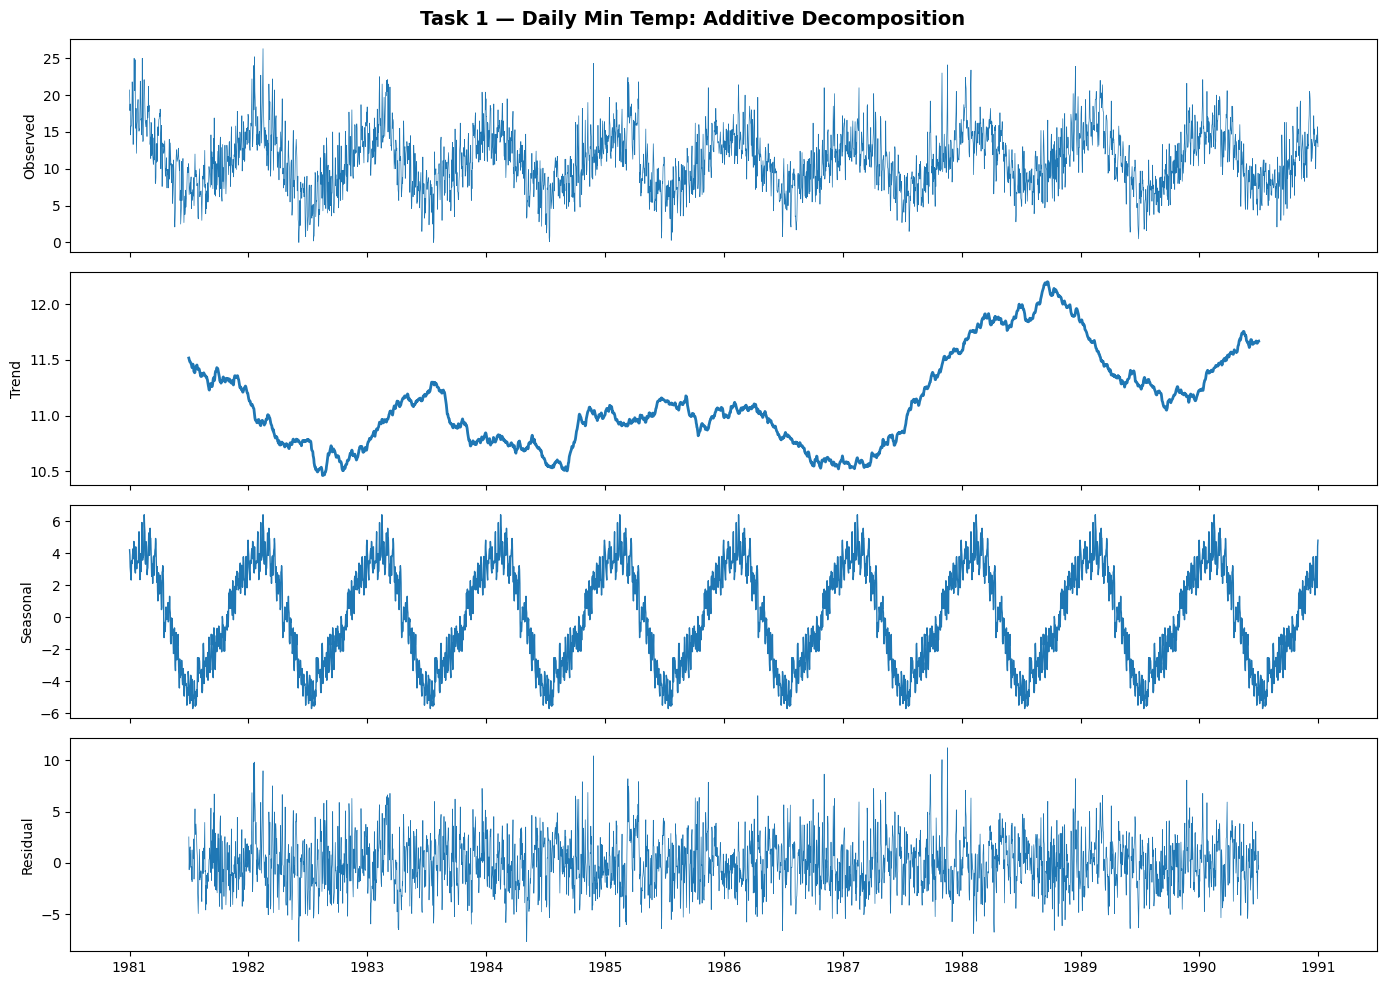

In [ ]:
# ============================================================
# TASK 1 — EXPLORING TIME SERIES PATTERNS
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv("1_Daily_minimum_temps.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
df.set_index('Date', inplace=True)

df['Temp'] = df['Temp'].astype(str).str.replace('?', '', regex=False)
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

df = df.dropna()

ts = df['Temp']

decomp = seasonal_decompose(ts, model='additive', period=365)

fig1, axes1 = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig1.suptitle('Task 1 — Daily Min Temp: Additive Decomposition', fontsize=14, fontweight='bold')

axes1[0].plot(ts, linewidth=0.5)
axes1[0].set_ylabel('Observed')

axes1[1].plot(decomp.trend, linewidth=2)
axes1[1].set_ylabel('Trend')

axes1[2].plot(decomp.seasonal, linewidth=1)
axes1[2].set_ylabel('Seasonal')

axes1[3].plot(decomp.resid, linewidth=0.5)
axes1[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()

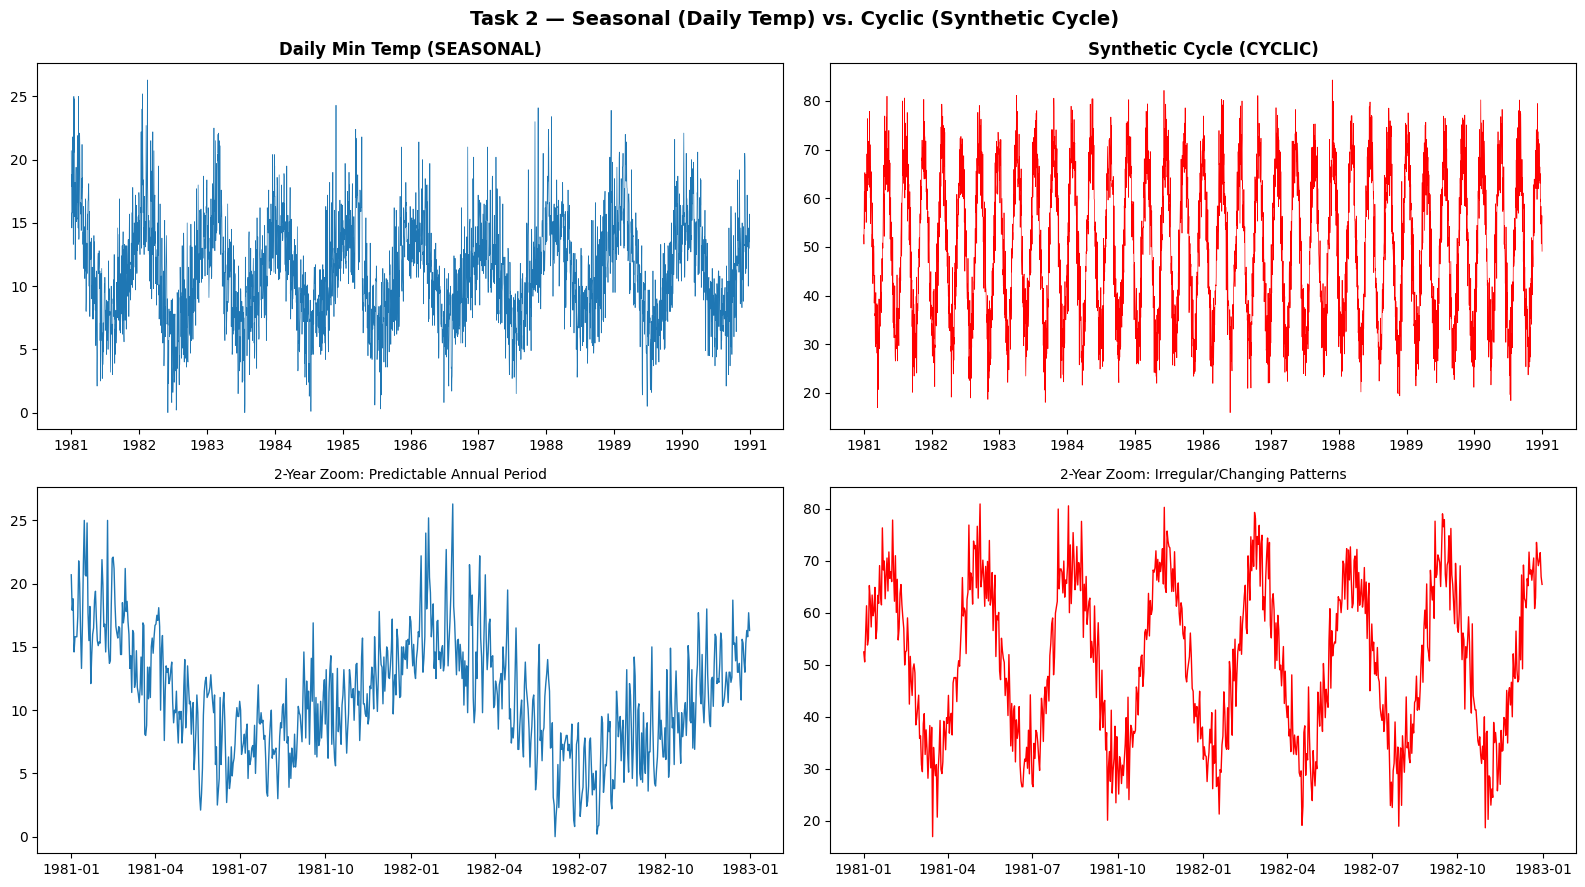

In [ ]:
# ============================================================
# TASK 2 — COMPARING CYCLIC VS. SEASONAL
# ============================================================
# Synthetic cyclic data to replace missing sunspots data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_idx = np.arange(len(ts))

cycle = 50 + 20 * np.sin(2 * np.pi * time_idx / 100) + np.random.normal(0, 5, len(ts))
cyclic_df = pd.Series(cycle, index=ts.index)

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 9))
fig2.suptitle('Task 2 — Seasonal (Daily Temp) vs. Cyclic (Synthetic Cycle)', fontsize=14, fontweight='bold')

axes2[0, 0].plot(ts, linewidth=0.5)
axes2[0, 0].set_title('Daily Min Temp (SEASONAL)', fontweight='bold')

axes2[1, 0].plot(ts.iloc[:730], linewidth=1)
axes2[1, 0].set_title('2-Year Zoom: Predictable Annual Period', fontsize=10)

axes2[0, 1].plot(cyclic_df, color='red', linewidth=0.5)
axes2[0, 1].set_title('Synthetic Cycle (CYCLIC)', fontweight='bold')

axes2[1, 1].plot(cyclic_df.iloc[:730], color='red', linewidth=1)
axes2[1, 1].set_title('2-Year Zoom: Irregular/Changing Patterns', fontsize=10)

plt.tight_layout()
plt.show()

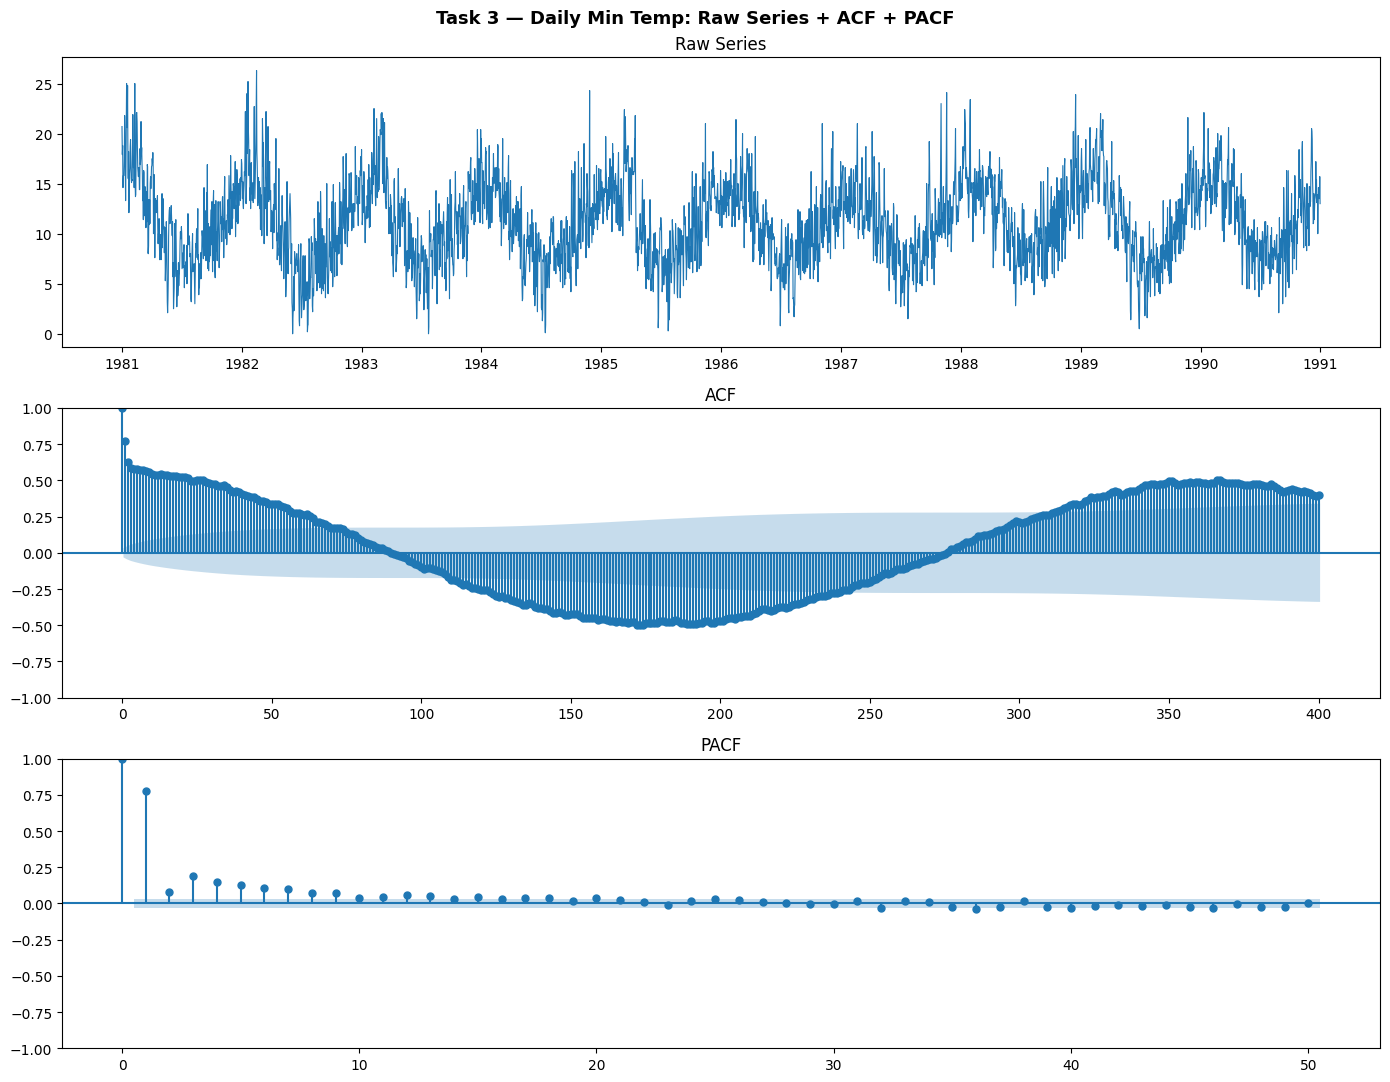

In [ ]:
# ============================================================
# TASK 3 — ACF & PACF ANALYSIS
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig3, axes3 = plt.subplots(3, 1, figsize=(14, 11))
fig3.suptitle('Task 3 — Daily Min Temp: Raw Series + ACF + PACF', fontsize=13, fontweight='bold')

axes3[0].plot(ts, linewidth=0.8)
axes3[0].set_title('Raw Series')

plot_acf(ts, lags=400, ax=axes3[1])
axes3[1].set_title('ACF')

plot_pacf(ts, lags=50, ax=axes3[2], method='ywm')
axes3[2].set_title('PACF')

plt.tight_layout()
plt.show()

--- ADF Test: Raw Temperature Data ---
ADF Statistic: -4.4448
p-value: 0.0002
✅ Result: Stationary (Reject Null Hypothesis)
------------------------------
--- ADF Test: First-Differenced Data (d=1) ---
ADF Statistic: -18.0282
p-value: 0.0000
✅ Result: Stationary (Reject Null Hypothesis)
------------------------------


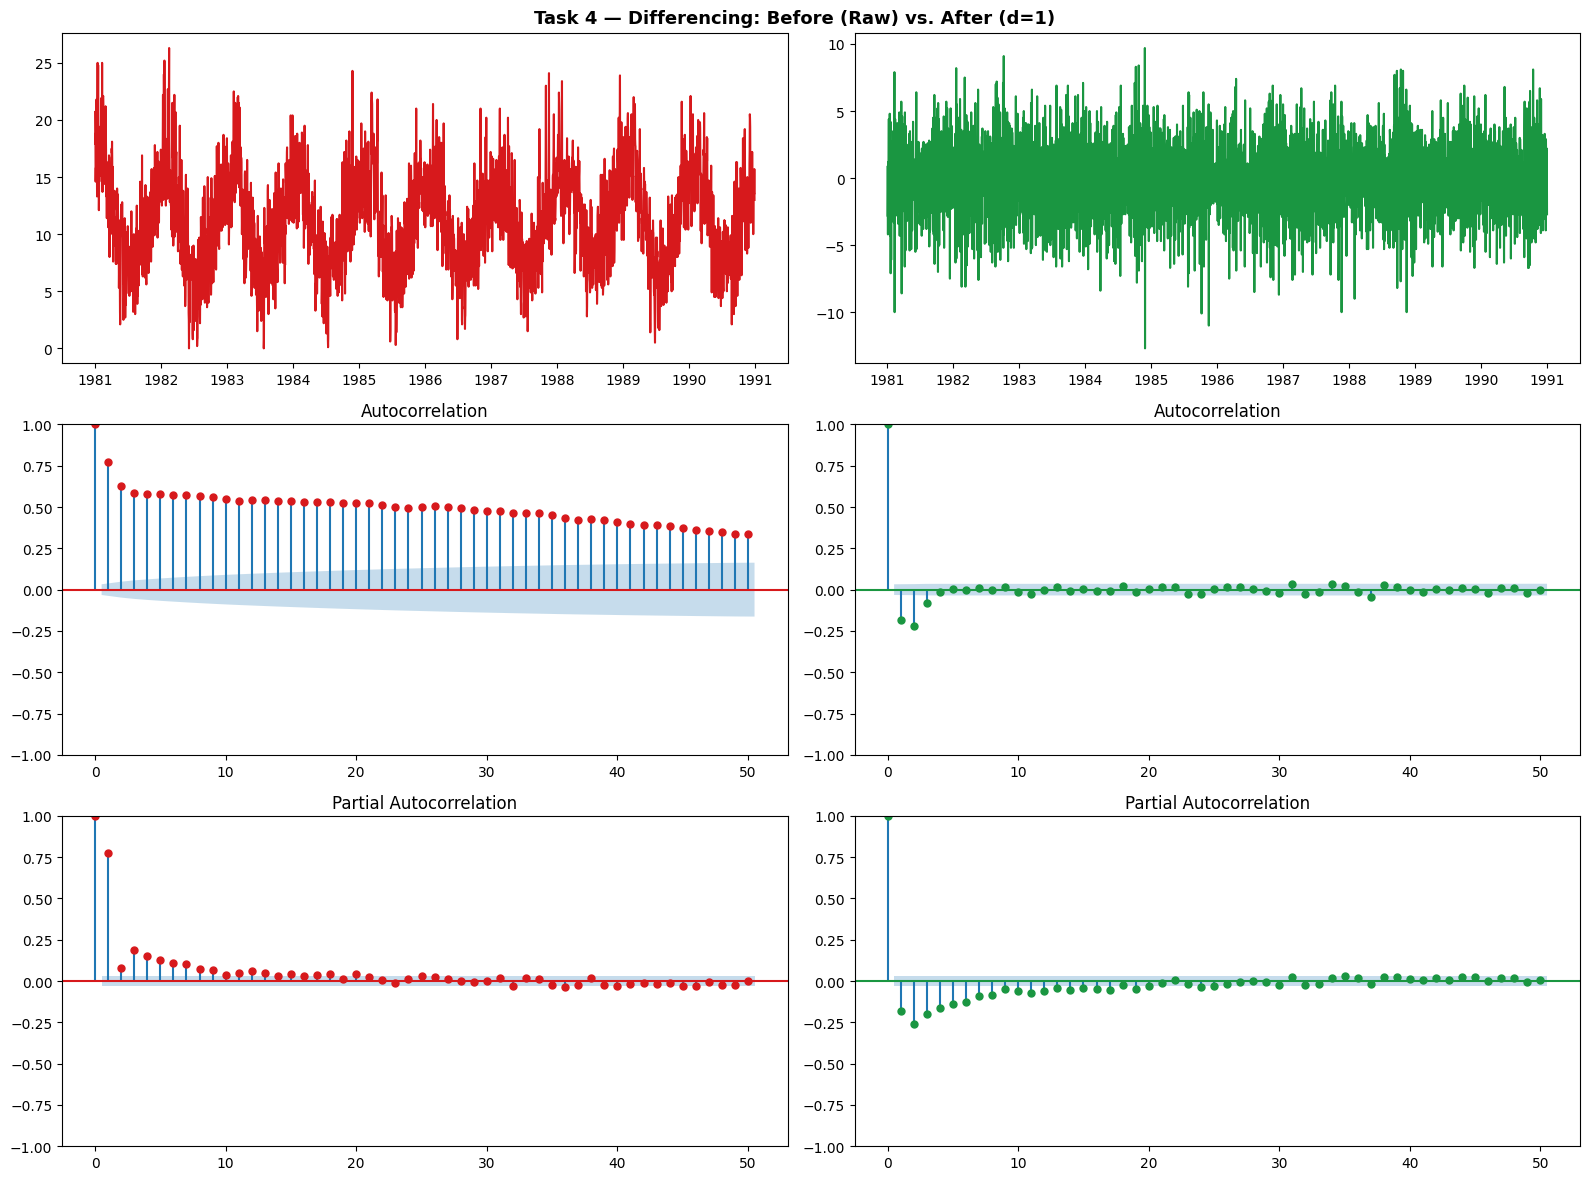

In [ ]:
# ============================================================
# TASK 4 — DIFFERENCING TO ACHIEVE STATIONARITY
# ============================================================
# ============================================================
# TASK 4 — DIFFERENCING TO ACHIEVE STATIONARITY
# ============================================================
ts_diff = ts.diff().dropna()
fig4, axes4 = plt.subplots(3, 2, figsize=(16, 12))
fig4.suptitle('Task 4 — Differencing: Before (Raw) vs. After (d=1)', fontsize=13, fontweight='bold')
axes4[0, 0].plot(ts, color='#d7191c'); axes4[0, 1].plot(ts_diff, color='#1a9641')
plot_acf(ts, lags=50, ax=axes4[1, 0], color='#d7191c')
plot_acf(ts_diff, lags=50, ax=axes4[1, 1], color='#1a9641')
plot_pacf(ts, lags=50, ax=axes4[2, 0], method='ywm', color='#d7191c')
plot_pacf(ts_diff, lags=50, ax=axes4[2, 1], method='ywm', color='#1a9641')
plt.tight_layout()
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, title):
    print(f"--- ADF Test: {title} ---")
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("✅ Result: Stationary (Reject Null Hypothesis)")
    else:
        print("❌ Result: Non-Stationary (Fail to Reject Null Hypothesis)")
    print("-" * 30)

# Apply to Task 4
check_stationarity(ts, "Raw Temperature Data")
ts_diff = ts.diff().dropna()
check_stationarity(ts_diff, "First-Differenced Data (d=1)")

In [ ]:
train_size = int(len(df) * 0.8)

train = df["Temp"][:train_size]
test = df["Temp"][train_size:]

print(len(train), len(test))

2920 730


In [ ]:
!pip install pmdarima

In [ ]:
#Auto-ARIMA (Task 5)
import pmdarima as pm
ts = df['Temp']
model = pm.auto_arima(
    ts,
    seasonal=False,
    stepwise=True,
    trace=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=16793.435, Time=4.95 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=28436.596, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=17652.487, Time=0.46 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=24521.185, Time=0.63 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=16831.280, Time=2.43 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=16842.806, Time=8.97 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=16837.182, Time=10.08 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=16793.171, Time=4.97 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=16791.401, Time=1.16 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=21089.063, Time=2.15 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=16793.303, Time=2.95 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=22320.266, Time=1.90 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=20360.550, Time=1.20 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=16794.611, Time=3.27 sec
 ARIMA(1,0,3)(0,0,

In [ ]:
print("ARIMA order:", model.order)

ARIMA order: (1, 0, 3)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

p, d, q = model.order

arima_model = ARIMA(ts, order=(p,d,q))
arima_result = arima_model.fit()

print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3650
Model:                 ARIMA(1, 0, 3)   Log Likelihood               -8383.390
Date:                Tue, 12 May 2026   AIC                          16778.780
Time:                        21:01:53   BIC                          16815.995
Sample:                             0   HQIC                         16792.033
                               - 3650                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.4770      0.805     14.254      0.000       9.899      13.055
ar.L1          0.9925      0.002    437.151      0.000       0.988       0.997
ma.L1         -0.4007      0.015    -26.268      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


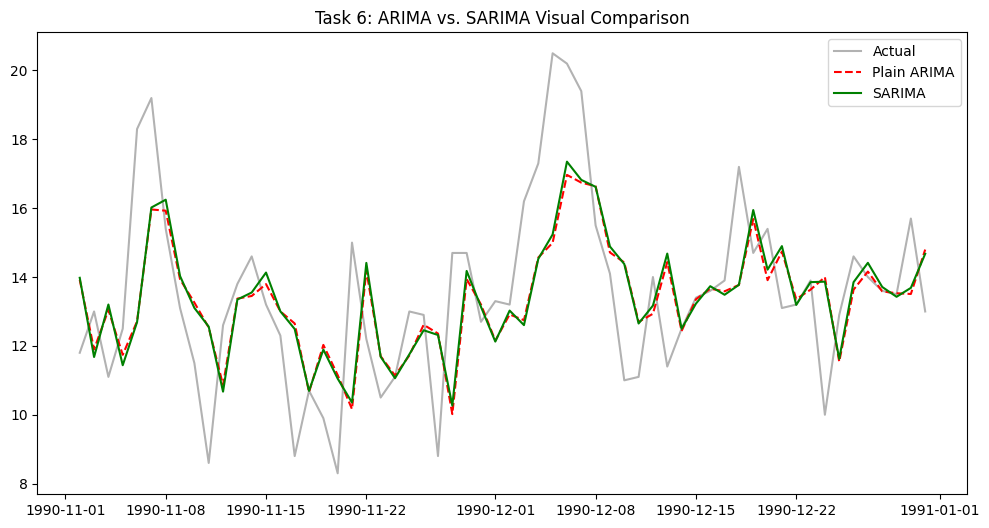

In [ ]:
#Task.6 ARIMA vs. SARIMA Visual Comparison
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA with weekly seasonality (s=7) for daily data
model_sarima = SARIMAX(df["Temp"], order=(1, 1, 2), seasonal_order=(1, 1, 1, 7))
results_sarima = model_sarima.fit()

# Visual Comparison
plt.figure(figsize=(12, 6))
plt.plot(df["Temp"].tail(60), label='Actual', color='black', alpha=0.3)
plt.plot(arima_result.predict(start=df.index[-60]), label='Plain ARIMA', color='red', linestyle='--')
plt.plot(results_sarima.predict(start=df.index[-60]), label='SARIMA', color='green')
plt.title("Task 6: ARIMA vs. SARIMA Visual Comparison")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

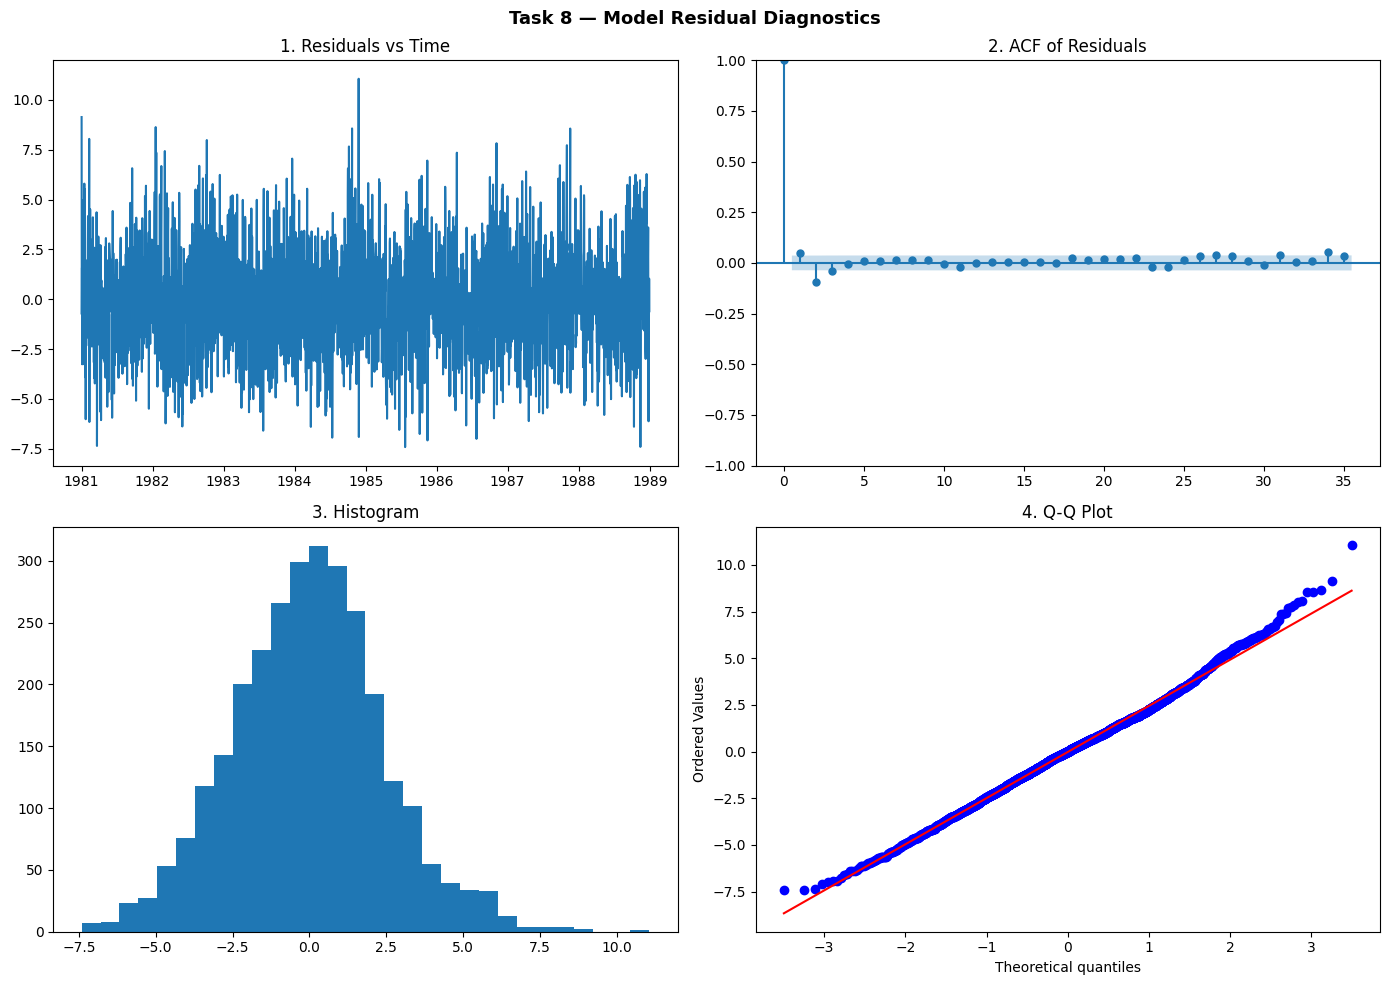

In [59]:
# ============================================================
# TASK 7 & 8 — FORECAST ACCURACY & DIAGNOSTICS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
from matplotlib.gridspec import GridSpec

split = int(len(ts) * 0.8)
train, test = ts.iloc[:split], ts.iloc[split:]

model = ARIMA(train, order=(2,0,1)).fit()
fc_series = pd.Series(model.forecast(steps=len(test)).values, index=test.index)

residuals = model.resid

fig8 = plt.figure(figsize=(14, 10))
fig8.suptitle('Task 8 — Model Residual Diagnostics', fontsize=13, fontweight='bold')

gs = GridSpec(2, 2, figure=fig8)

ax1 = fig8.add_subplot(gs[0, 0])
ax1.plot(residuals)
ax1.set_title('1. Residuals vs Time')

ax2 = fig8.add_subplot(gs[0, 1])
plot_acf(residuals, ax=ax2)
ax2.set_title('2. ACF of Residuals')

ax3 = fig8.add_subplot(gs[1, 0])
ax3.hist(residuals, bins=30)
ax3.set_title('3. Histogram')

ax4 = fig8.add_subplot(gs[1, 1])
stats.probplot(residuals, plot=ax4)
ax4.set_title('4. Q-Q Plot')

plt.tight_layout()
plt.show()

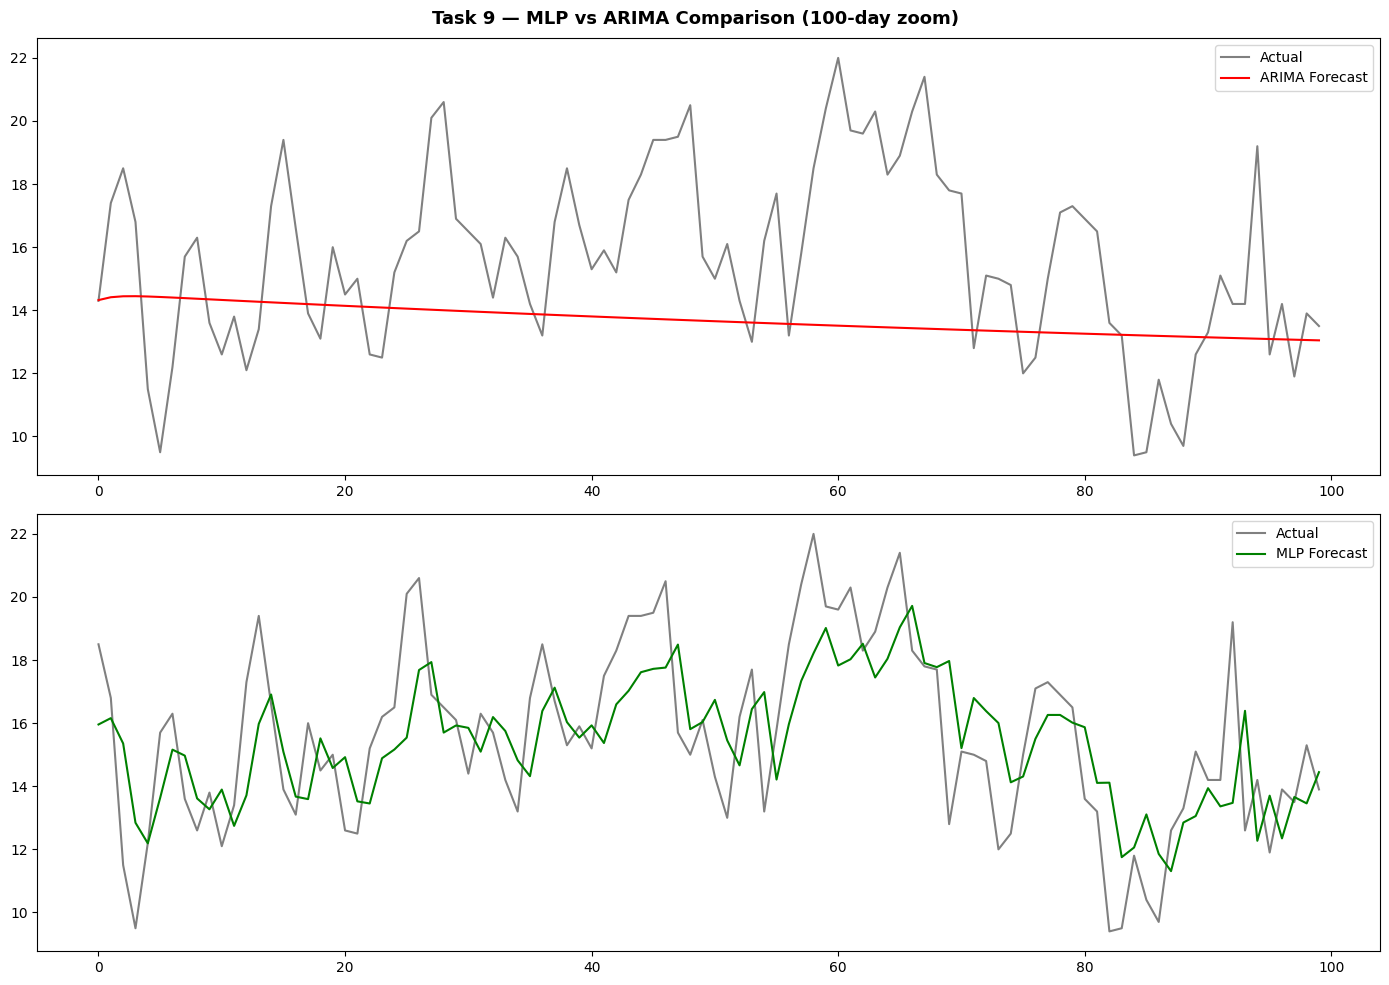

In [ ]:
# ============================================================
# TASK 9 MLP & ARIMA Model Comparsion
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor

N_LAGS = 14

def make_supervised(series, n_lags):
    df = pd.DataFrame({'y': series.values})
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df['y'].shift(i)
    df = df.dropna()
    X = df.drop('y', axis=1)
    y = df['y']
    return X, y

X, y = make_supervised(ts, N_LAGS)

split_m = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_m], X.iloc[split_m:]
y_train, y_test = y.iloc[:split_m], y.iloc[split_m:]

scaler = MinMaxScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
mlp.fit(X_tr_s, y_train)

mlp_preds = mlp.predict(X_te_s)

fig9, axes9 = plt.subplots(2, 1, figsize=(14, 10))
fig9.suptitle('Task 9 — MLP vs ARIMA Comparison (100-day zoom)', fontsize=13, fontweight='bold')

axes9[0].plot(test.values[:100], color='gray', label='Actual')
axes9[0].plot(fc_series.values[:100], color='red', label='ARIMA Forecast')
axes9[0].legend()

axes9[1].plot(y_test.values[:100], color='gray', label='Actual')
axes9[1].plot(mlp_preds[:100], color='green', label='MLP Forecast')
axes9[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── TASK 9 & 10: FINAL COMPARISON TABLE ──
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================
# ALIGN ARRAYS SAFELY
# =========================

arima_pred = np.array(fc_series)
actual = np.array(test)

test_actual = np.array(y_test)
test_nn_pred = np.array(mlp_preds)

# =========================
# METRICS
# =========================
rmse_arima = np.sqrt(mean_squared_error(actual, arima_pred))
mae_arima = mean_absolute_error(actual, arima_pred)

rmse_mlp = np.sqrt(mean_squared_error(test_actual, test_nn_pred))
mae_mlp = mean_absolute_error(test_actual, test_nn_pred)

# =========================
# TABLE
# =========================
comparison_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE"],
    "ARIMA (Classical)": [round(rmse_arima, 4), round(mae_arima, 4)],
    "Neural Network (MLP)": [round(rmse_mlp, 4), round(mae_mlp, 4)]
})

print("--- Final Model Comparison ---")
print(comparison_df.to_string(index=False))

# =========================
# WINNER
# =========================
winner = "ARIMA" if rmse_arima < rmse_mlp else "Neural Network (MLP)"

print(f"\nRecommended Model for Report: {winner}")

--- Final Model Comparison ---
Metric  ARIMA (Classical)  Neural Network (MLP)
  RMSE             4.0424                2.2169
   MAE             3.3272                1.7502

Recommended Model for Report: Neural Network (MLP)
